# RQ3 — Carbon-Aware Hyperparameter Optimization

         Method      RMSE   R2Score  RuntimeSeconds  EstimatedCO2
0    GridSearch  1.876187  0.986785      126.337978      2.526760
1  RandomSearch  1.876187  0.986785       46.759452      0.935189


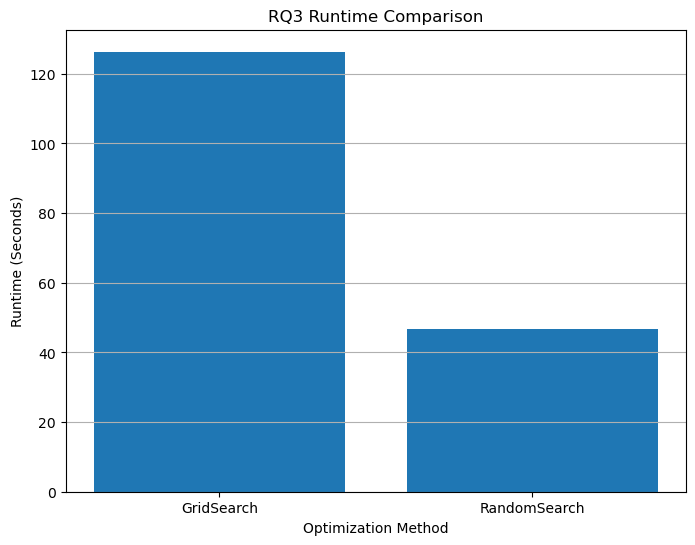

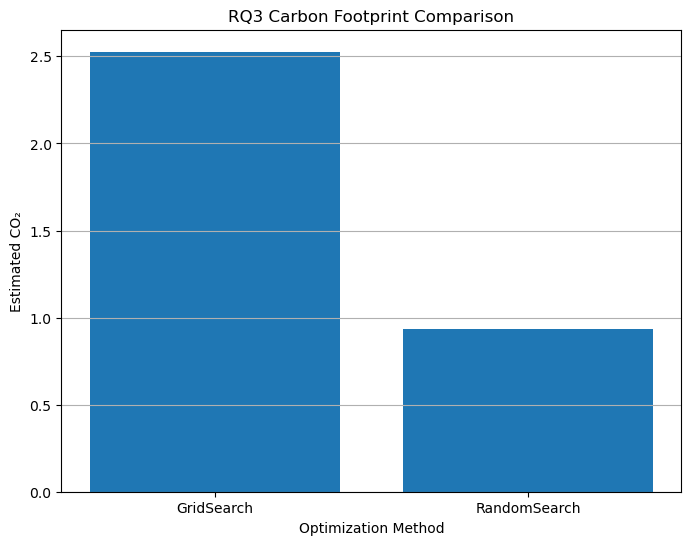

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor

# ====================================
# Load Dataset
# ====================================

df = pd.read_csv("iiot_smart_grid_dataset.csv")

# Remove Timestamp if present
if "Timestamp" in df.columns:
    df = df.drop("Timestamp", axis=1)

df = df.dropna()

# Encode categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# ====================================
# Features and Target
# ====================================

X = df.drop("Energy_Efficiency_Score", axis=1)
y = df["Energy_Efficiency_Score"]

# ====================================
# Train-Test Split
# ====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ====================================
# Parameter Grid
# ====================================

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10]
}

results = []

# ====================================
# Grid Search
# ====================================

start = time.time()

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="r2"
)

grid.fit(X_train, y_train)

runtime = time.time() - start

preds = grid.predict(X_test)

rmse = np.sqrt(
    mean_squared_error(y_test, preds)
)

r2 = r2_score(y_test, preds)

estimated_co2 = runtime * 0.02

results.append([
    "GridSearch",
    rmse,
    r2,
    runtime,
    estimated_co2
])

# ====================================
# Random Search
# ====================================

start = time.time()

random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    n_iter=2,
    cv=3,
    scoring="r2",
    random_state=42
)

random.fit(X_train, y_train)

runtime = time.time() - start

preds = random.predict(X_test)

rmse = np.sqrt(
    mean_squared_error(y_test, preds)
)

r2 = r2_score(y_test, preds)

estimated_co2 = runtime * 0.02

results.append([
    "RandomSearch",
    rmse,
    r2,
    runtime,
    estimated_co2
])

# ====================================
# Results Table
# ====================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Method",
        "RMSE",
        "R2Score",
        "RuntimeSeconds",
        "EstimatedCO2"
    ]
)

print(results_df)

results_df.to_csv(
    "RQ3_results_table.csv",
    index=False
)

# ====================================
# Figure 1
# Runtime Comparison
# ====================================

plt.figure(figsize=(8,6))

plt.bar(
    results_df["Method"],
    results_df["RuntimeSeconds"]
)

plt.xlabel("Optimization Method")
plt.ylabel("Runtime (Seconds)")
plt.title("RQ3 Runtime Comparison")

plt.grid(axis="y")

plt.savefig(
    "RQ3_runtime_comparison.pdf",
    bbox_inches="tight"
)

plt.show()

# ====================================
# Figure 2
# Carbon Comparison
# ====================================

plt.figure(figsize=(8,6))

plt.bar(
    results_df["Method"],
    results_df["EstimatedCO2"]
)

plt.xlabel("Optimization Method")
plt.ylabel("Estimated CO₂")
plt.title("RQ3 Carbon Footprint Comparison")

plt.grid(axis="y")

plt.savefig(
    "RQ3_carbon_comparison.pdf",
    bbox_inches="tight"
)

plt.show()